In [46]:
import warnings
warnings.filterwarnings("ignore")

In [47]:
# importações e ajustes de formatação
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
pd.options.display.float_format = '{:,.2f}'.format

# Case Liv Up - Programa de Estágio (Business Analytics)<br>
### Contexto e Desafio:
A Liv Up quer expandir seu negócio para mais 2 cidades. Atualmente existem 3 categorias de itens:<br> Arroz e feijão, Fitness e Especiais.
<br><br>
### Pergunta inicial:
Traga uma sugestão de cidade e duas categorias que você consideraria para este projeto,
buscando a melhor combinação de cidade/categoria que seja mais rentável no menor
tempo.<br>Considere que o pedido médio total não mudará e que os preços se manterão por
todo o Brasil.
<br><br>
### Pergunta Final:
Se você pudesse escolher algo para aumentar a rentabilidade, qual métrica você melhoraria
e porquê?
<br><br>
*Obs.: deixei isso no notebook para usar de guia sem precisar ficar voltando no PDF*

# <br> Preparando o material
Nessa primeira parte eu gosto de preparar o material que vou usar para realizar as análises.
O objetivo desse preparo é deixar tudo no jeito e pronto para poder modelar e chegar nos resultados.
É basicamente separar as ferramentas e materiais antes de começar uma obra, por exemplo.

## Criando e modelando as tabelas a serem usadas

In [48]:
# Importando nosso banco de dados que contém os dados do Case
# Fiz uma cópia do banco de dados fornecido e separei as tabelas em páginas para simplificar/agilizar a criação das tabelas
banco_de_dados = './Case Liv Up - Business Analytics.xlsx'

In [49]:
# Criando e ajustando a tabela 1 (Informações sobre o carrinho médio da empresa)
carrinho_medio_completo = pd.read_excel(banco_de_dados, sheet_name= 'Tabela 1')
carrinho_medio_completo

,Categoria,Publico Aderente,Peso Médio [g],Preço Médio,Share de Vendas Todas as Praças,Unidades Médias por Pedido,TM por Cat,Custo produção/ UND
0,Arroz e Feijão,E D C2,300.00,11.00,0.40,8.00,88.00,2.50
1,Fitness,D C,350.00,15.00,0.40,8.00,120.00,7.00
2,Especiais,B2 B1 A,300.00,22.00,0.20,4.00,88.00,12.00
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Valores Totais,-,"103,600.00","4,440.00",1.00,20.00,296.00,"2,072.00"


In [50]:
# Limpando linha vazia no Data Frame
carrinho_medio_completo.dropna(ignore_index= True, inplace= True)
carrinho_medio_completo

,Categoria,Publico Aderente,Peso Médio [g],Preço Médio,Share de Vendas Todas as Praças,Unidades Médias por Pedido,TM por Cat,Custo produção/ UND
0,Arroz e Feijão,E D C2,300.00,11.00,0.40,8.00,88.00,2.50
1,Fitness,D C,350.00,15.00,0.40,8.00,120.00,7.00
2,Especiais,B2 B1 A,300.00,22.00,0.20,4.00,88.00,12.00
3,Valores Totais,-,"103,600.00","4,440.00",1.00,20.00,296.00,"2,072.00"


In [51]:
# Criando um Data Frame sem as linhas de valores totais
# Fazendo uma pré-análise rapidinha, eu não acho que eu vá realmente usar os valores totais do carrinho, caso eu precise terei
# as duas tabelas à disposição
carrinho_medio = carrinho_medio_completo.drop(3)
carrinho_medio

,Categoria,Publico Aderente,Peso Médio [g],Preço Médio,Share de Vendas Todas as Praças,Unidades Médias por Pedido,TM por Cat,Custo produção/ UND
0,Arroz e Feijão,E D C2,300.00,11.00,0.40,8.00,88.00,2.50
1,Fitness,D C,350.00,15.00,0.40,8.00,120.00,7.00
2,Especiais,B2 B1 A,300.00,22.00,0.20,4.00,88.00,12.00


---

In [52]:
# Criando e ajustando a tabela 2 (Informações demográficas sobre as cidades)
# Essa já veio no jeito
demografia_cidades = pd.read_excel(banco_de_dados, sheet_name= 'Tabela 2')
demografia_cidades

,Município,E,D,C2,C1,B2,B1,A,Total,Custo de Entrega - Por venda,Custo de Marketing - Por Venda
0,Cidade Z,11202,49283,118458,95088,28795,9930,4466,317222,10.00,50
1,Cidade X,20993,91078,111801,72920,28937,12333,5036,343098,7.00,35
2,Cidade Y,24914,87807,125282,91960,38711,14935,6997,390606,15.00,40
3,Cidade W,19558,70687,140643,113634,43999,18353,8848,415722,7.50,50
4,Cidade G,36051,123909,193769,126914,50140,19027,8971,558781,40.00,20
5,Cidade F,74372,185084,150608,90971,38836,16487,8307,564665,25.00,50


---

In [53]:
# Criando e ajustando a tabela 3 (Informações sobre o consumo potencial histórico por Classe social da empresa)
# Essa também já veio no jeito
consumo_potencial_classe = pd.read_excel(banco_de_dados, sheet_name = 'Tabela 3')
consumo_potencial_classe

,Classe,E,D,C2,C1,B2,B1,A
0,Inserção,0.01,0.02,0.07,0.09,0.10,0.12,0.25


In [54]:
# Alterando a orientação da tabela para melhor visualização e utilização
consumo_potencial_classe = consumo_potencial_classe.T
consumo_potencial_classe = consumo_potencial_classe[1:]
consumo_potencial_classe.rename(columns={'index': 'Classe', 0 : 'Inserção'}, inplace=True)
consumo_potencial_classe

,Inserção
E,0.01
D,0.02
C2,0.07
C1,0.09
B2,0.10
B1,0.12
A,0.25


---

In [55]:
# Visualizando as 3 tabelas já modeladas
display('Tabela 1 (Informações sobre o carrinho médio da empresa):', carrinho_medio)
display('Tabela 2 (Informações demográficas sobre as cidades):', demografia_cidades)
display('Tabela 3 (Informações sobre o consumo potencial histórico por Classe social da empresa):', consumo_potencial_classe)

'Tabela 1 (Informações sobre o carrinho médio da empresa):'

,Categoria,Publico Aderente,Peso Médio [g],Preço Médio,Share de Vendas Todas as Praças,Unidades Médias por Pedido,TM por Cat,Custo produção/ UND
0,Arroz e Feijão,E D C2,300.00,11.00,0.40,8.00,88.00,2.50
1,Fitness,D C,350.00,15.00,0.40,8.00,120.00,7.00
2,Especiais,B2 B1 A,300.00,22.00,0.20,4.00,88.00,12.00


'Tabela 2 (Informações demográficas sobre as cidades):'

,Município,E,D,C2,C1,B2,B1,A,Total,Custo de Entrega - Por venda,Custo de Marketing - Por Venda
0,Cidade Z,11202,49283,118458,95088,28795,9930,4466,317222,10.00,50
1,Cidade X,20993,91078,111801,72920,28937,12333,5036,343098,7.00,35
2,Cidade Y,24914,87807,125282,91960,38711,14935,6997,390606,15.00,40
3,Cidade W,19558,70687,140643,113634,43999,18353,8848,415722,7.50,50
4,Cidade G,36051,123909,193769,126914,50140,19027,8971,558781,40.00,20
5,Cidade F,74372,185084,150608,90971,38836,16487,8307,564665,25.00,50


'Tabela 3 (Informações sobre o consumo potencial histórico por Classe social da empresa):'

,Inserção
E,0.01
D,0.02
C2,0.07
C1,0.09
B2,0.10
B1,0.12
A,0.25


## Calculando % de cada classe por cidade

In [56]:
# Separando o número da população por classe e número total
pop_cidade = demografia_cidades.loc[:, 'E':'A']
pop_total = demografia_cidades['Total']

# Calculando o percentual de cada classe presente na população total (pop. da classe / pop. total * 100)
porcentagem_lista = list()
for i in pop_cidade:
    porcentagem_lista.append(((pop_cidade[i] / pop_total) * 100))
    
# Colocando o resultado em um Data Frame para podermos utilizar
columns = pop_cidade.columns
demografia_percentual = pd.DataFrame(porcentagem_lista).T
demografia_percentual.columns = columns + ' (%)'
demografia_percentual.insert(0, 'Município', demografia_cidades['Município'])
demografia_percentual['Total'] = demografia_cidades['Total']
demografia_percentual

,Município,E (%),D (%),C2 (%),C1 (%),B2 (%),B1 (%),A (%),Total
0,Cidade Z,3.53,15.54,37.34,29.98,9.08,3.13,1.41,317222
1,Cidade X,6.12,26.55,32.59,21.25,8.43,3.59,1.47,343098
2,Cidade Y,6.38,22.48,32.07,23.54,9.91,3.82,1.79,390606
3,Cidade W,4.70,17.00,33.83,27.33,10.58,4.41,2.13,415722
4,Cidade G,6.45,22.17,34.68,22.71,8.97,3.41,1.61,558781
5,Cidade F,13.17,32.78,26.67,16.11,6.88,2.92,1.47,564665


## Calculando clientes potenciais: 
  - por classe (por cidade)
  - totais por cidade

In [57]:
# Criando variáveis que servirão como filtro para criação do Data Frame
insercao = consumo_potencial_classe['Inserção'].to_dict()
classes = consumo_potencial_classe.index.to_list()
pot_clientes= pd.DataFrame()

# Criando o Data Frame com os potenciais clientes por classe (por cidade)
for classe in classes:
    pot_clientes[classe] = (demografia_cidades[classe] * insercao[classe]).astype(int)

pot_clientes.insert(0, 'Município', demografia_cidades['Município'])
pot_clientes = pd.concat([pot_clientes, demografia_cidades['Total'], demografia_cidades['Custo de Entrega - Por venda'],
                          demografia_cidades['Custo de Marketing - Por Venda']], axis = 1)
pot_clientes

,Município,E,D,C2,C1,B2,B1,A,Total,Custo de Entrega - Por venda,Custo de Marketing - Por Venda
0,Cidade Z,112,985,8292,8557,2879,1191,1116,317222,10.00,50
1,Cidade X,209,1821,7826,6562,2893,1479,1259,343098,7.00,35
2,Cidade Y,249,1756,8769,8276,3871,1792,1749,390606,15.00,40
3,Cidade W,195,1413,9845,10227,4399,2202,2212,415722,7.50,50
4,Cidade G,360,2478,13563,11422,5014,2283,2242,558781,40.00,20
5,Cidade F,743,3701,10542,8187,3883,1978,2076,564665,25.00,50


In [58]:
# Adicionando a coluna de potenciais clientes totais por cidade
pot_clientes.insert(8, 'Total_pot', pot_clientes.loc[:, 'E':'A'].sum(axis= 1))
pot_clientes

,Município,E,D,C2,C1,B2,B1,A,Total_pot,Total,Custo de Entrega - Por venda,Custo de Marketing - Por Venda
0,Cidade Z,112,985,8292,8557,2879,1191,1116,23132,317222,10.00,50
1,Cidade X,209,1821,7826,6562,2893,1479,1259,22049,343098,7.00,35
2,Cidade Y,249,1756,8769,8276,3871,1792,1749,26462,390606,15.00,40
3,Cidade W,195,1413,9845,10227,4399,2202,2212,30493,415722,7.50,50
4,Cidade G,360,2478,13563,11422,5014,2283,2242,37362,558781,40.00,20
5,Cidade F,743,3701,10542,8187,3883,1978,2076,31110,564665,25.00,50


## Mapeando as categorias

In [59]:
# Mapeando as categorias e classes usando os dados da Tabela 1
cat_classes = carrinho_medio[:3][['Categoria','Publico Aderente']]
cat_classes.set_index('Categoria', inplace = True)
cat_classes = cat_classes['Publico Aderente'].to_dict()

for key in cat_classes:
    cat_classes[key] = cat_classes[key].split()

In [60]:
# Na categoria 'Fitness' um dos públicos aderentes é representado apenas por 'C', englobando 'C1' e 'C2'
# Vou substituir o 'C' por 'C1' e 'C2'
cat_classes['Fitness'] = ['D', 'C2', 'C1']
cat_classes

{'Arroz e Feijão': ['E', 'D', 'C2'],
 'Fitness': ['D', 'C2', 'C1'],
 'Especiais': ['B2', 'B1', 'A']}

# <br>Cálculos centrais

## Cruzando os dados para obter os resultados
Com tudo pronto, chegou a hora de botar a mão na massa para chegar nos resultados esperados propostos pelo case.

<br>Vou estruturar a tabela da seguinte forma, para cada **cidade x categoria**:

- clientes = soma dos clientes potenciais nas classes aderentes
- receita por cliente = ticket médio por categoria
- custo total por venda = custo de marketing por venda + custo de entrega por venda + custo de produção (unidades média por pedido * custo de produção da unidade)
- lucro por cliente = receita por cliente - custo total por venda
- receita total = receita por cliente * clientes
- lucro total = lucro por cliente * clientes

In [61]:
# Criando o Data Frame com todos os resultados dos nossos cálculos
resultados = list()

for _, cidade in pot_clientes.iterrows():
    for _, cat in carrinho_medio.iterrows():
        cat_nome = cat['Categoria']
        classes_alvo = cat_classes[cat_nome]
        clientes = sum([cidade[classe] for classe in classes_alvo])
        receita_por_cliente = cat['TM por Cat']
        custo_marketing = cidade['Custo de Marketing - Por Venda']
        custo_entrega = cidade['Custo de Entrega - Por venda']
        custo_producao = cat['Unidades Médias por Pedido'] * cat['Custo produção/ UND']
        custo_total_venda = custo_marketing + custo_entrega + custo_producao
        lucro_por_cliente = receita_por_cliente - custo_total_venda
        lucro_total = lucro_por_cliente * clientes
        receita_total = receita_por_cliente * clientes

        resultados.append({
            'Municipio': cidade['Município'],
            'Categoria': cat_nome,
            'Clientes': clientes,
            'Receita_por_cliente': receita_por_cliente,
            'Custo_total_por_venda':custo_total_venda,
            'Lucro_por_cliente': lucro_por_cliente,
            'Receita_total': receita_total,
            'Lucro_total': lucro_total
        })

cid_x_cat = pd.DataFrame(resultados)
cid_x_cat

,Municipio,Categoria,Clientes,Receita_por_cliente,Custo_total_por_venda,Lucro_por_cliente,Receita_total,Lucro_total
0,Cidade Z,Arroz e Feijão,9389,88.00,80.00,8.00,"826,232.00","75,112.00"
1,Cidade Z,Fitness,17834,120.00,116.00,4.00,"2,140,080.00","71,336.00"
2,Cidade Z,Especiais,5186,88.00,108.00,-20.00,"456,368.00","-103,720.00"
3,Cidade X,Arroz e Feijão,9856,88.00,62.00,26.00,"867,328.00","256,256.00"
4,Cidade X,Fitness,16209,120.00,98.00,22.00,"1,945,080.00","356,598.00"
5,Cidade X,Especiais,5631,88.00,90.00,-2.00,"495,528.00","-11,262.00"
6,Cidade Y,Arroz e Feijão,10774,88.00,75.00,13.00,"948,112.00","140,062.00"
7,Cidade Y,Fitness,18801,120.00,111.00,9.00,"2,256,120.00","169,209.00"
8,Cidade Y,Especiais,7412,88.00,103.00,-15.00,"652,256.00","-111,180.00"
9,Cidade W,Arroz e Feijão,11453,88.00,77.50,10.50,"1,007,864.00","120,256.50"


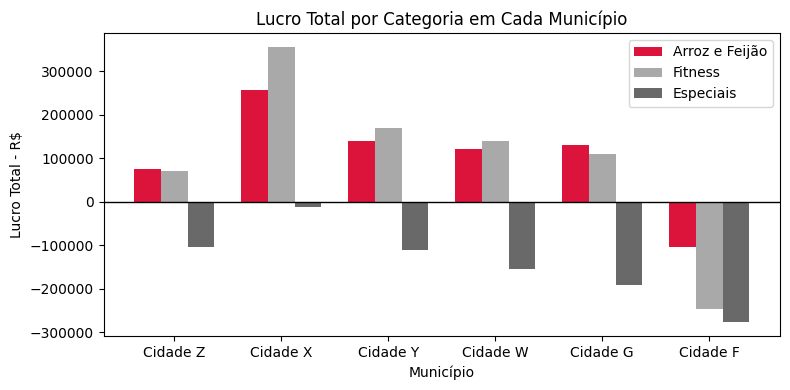

In [62]:
# Gráfico simples: visualizando os resultados dos cálculos
df_plot = cid_x_cat.copy()

plt.figure(figsize=(8, 4))

# categorias para agrupar barras
categorias = df_plot["Categoria"].unique()
x = df_plot["Municipio"].unique()
x_pos = range(len(x))
bar_width = 0.25

# plot por categoria (barras lado a lado)
cores = ["crimson", "darkgray", "dimgray"] 
for i, cat in enumerate(categorias):
    subset = df_plot[df_plot["Categoria"] == cat]
    plt.bar(
        [pos + i*bar_width for pos in x_pos],
        subset["Lucro_total"],
        width=bar_width,
        label=cat,
        color=cores[i]
    )

# eixo X com nome das cidades no centro do grupo
plt.xticks([pos + bar_width for pos in x_pos], x)

plt.axhline(0, color='black', linewidth=1)

plt.ylabel("Lucro Total - R$")
plt.xlabel("Município")
plt.title("Lucro Total por Categoria em Cada Município")
plt.legend()
plt.tight_layout()
plt.show()

## Ranking das melhores combinações cidade x categoria (por Lucro Total)

In [63]:
# Criando a variável 'top10' para fazer o gráfico com as 10 melhores combinações
top10 = cid_x_cat.sort_values('Lucro_total', ascending = False).reset_index(drop = True).head(10)

# Visualizando a tabela com o desempenho de todas as combinações
cid_x_cat.sort_values('Lucro_total', ascending = False).reset_index(drop = True)

,Municipio,Categoria,Clientes,Receita_por_cliente,Custo_total_por_venda,Lucro_por_cliente,Receita_total,Lucro_total
0,Cidade X,Fitness,16209,120.00,98.00,22.00,"1,945,080.00","356,598.00"
1,Cidade X,Arroz e Feijão,9856,88.00,62.00,26.00,"867,328.00","256,256.00"
2,Cidade Y,Fitness,18801,120.00,111.00,9.00,"2,256,120.00","169,209.00"
3,Cidade Y,Arroz e Feijão,10774,88.00,75.00,13.00,"948,112.00","140,062.00"
4,Cidade W,Fitness,21485,120.00,113.50,6.50,"2,578,200.00","139,652.50"
5,Cidade G,Arroz e Feijão,16401,88.00,80.00,8.00,"1,443,288.00","131,208.00"
6,Cidade W,Arroz e Feijão,11453,88.00,77.50,10.50,"1,007,864.00","120,256.50"
7,Cidade G,Fitness,27463,120.00,116.00,4.00,"3,295,560.00","109,852.00"
8,Cidade Z,Arroz e Feijão,9389,88.00,80.00,8.00,"826,232.00","75,112.00"
9,Cidade Z,Fitness,17834,120.00,116.00,4.00,"2,140,080.00","71,336.00"


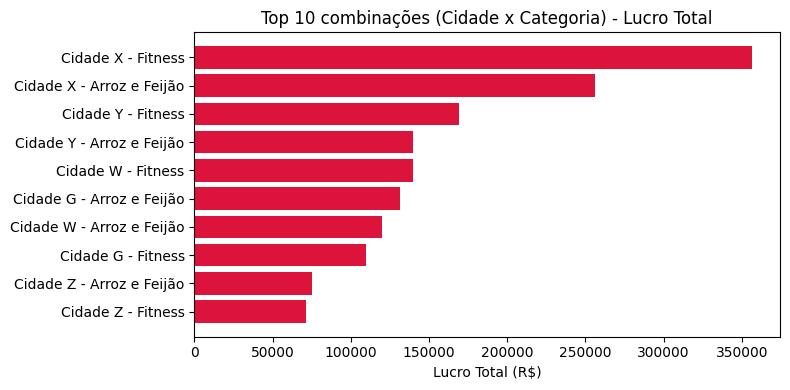

In [64]:
# Gráfico simples: visualizando o lucro total por combinação (top 10)

plt.figure(figsize=(8, 4))
plt.barh(top10['Municipio'] + ' - ' + top10['Categoria'], top10['Lucro_total'], color = 'crimson')
plt.xlabel('Lucro Total (R$)')
plt.title('Top 10 combinações (Cidade x Categoria) - Lucro Total')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Nem tudo são mil maravilhas...
Acharam que eu tinha esquecido, mas na descrição do case havia escrito bem grande e em negrito:<br><br>
    ***OBS:*** *Considere que ao abrir uma cidade, não consegue-se atingir todo o público e com 
    isso, iniciativas de marketing tem que ser mais caras, para criar conhecimento de marca e 
    fazer com que o público comece a consumir os produtos. Dessa forma o CAC é maior e o 
    número de clientes totais menor, até que se atinja a maturidade da região. Leve em 
    consideração estes fatores em seu cálculo, onde os clientes vão aumentando até chegar 
    em um patamar e o acréscimo no CAC no mesmo período.*

In [65]:
# Criando função para simular a maturidade e projeção de lucro, e entender o comportamento de cada categoria em cada cidade
def simular_maturidade(df, meses=24, curva_rapidez=0.25):
    resultados = []

    for idx, row in df.iterrows():
        municipio = row['Municipio']
        categoria = row['Categoria']
        clientes_max = row['Clientes']
        receita_por_cliente = row['Receita_por_cliente']
        custo_total = row['Custo_total_por_venda']
        lucro_por_cliente = row['Lucro_por_cliente']

        # Curva de maturidade
        t = np.arange(meses)
        maturidade = 1 / (1 + np.exp(-curva_rapidez*(t - meses/2)))

        clientes_mes = clientes_max * maturidade
        receita_mes = clientes_mes * receita_por_cliente
        lucro_mes = clientes_mes * lucro_por_cliente

        for mes in range(meses):
            resultados.append({
                'Municipio': municipio,
                'Categoria': categoria,
                'Mes': mes + 1,
                'Clientes_estimados': clientes_mes[mes],
                'Receita_estimado': receita_mes[mes],
                'Lucro_estimado': lucro_mes[mes]
            })

    return pd.DataFrame(resultados)

# Rodar simulação
df_projecao = simular_maturidade(cid_x_cat)

# Teste para entender o Data Frame
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade X'].loc[df_projecao['Categoria'] == 'Arroz e Feijão']
df

,Municipio,Categoria,Mes,Clientes_estimados,Receita_estimado,Lucro_estimado
72,Cidade X,Arroz e Feijão,1,467.43,"41,133.79","12,153.16"
73,Cidade X,Arroz e Feijão,2,592.21,"52,114.83","15,397.56"
74,Cidade X,Arroz e Feijão,3,747.66,"65,793.92","19,439.11"
75,Cidade X,Arroz e Feijão,4,939.76,"82,699.26","24,433.87"
76,Cidade X,Arroz e Feijão,5,"1,174.86","103,388.03","30,546.46"
77,Cidade X,Arroz e Feijão,6,"1,459.15","128,405.48","37,937.98"
78,Cidade X,Arroz e Feijão,7,"1,797.99","158,222.76","46,747.64"
79,Cidade X,Arroz e Feijão,8,"2,194.93","193,154.07","57,068.25"
80,Cidade X,Arroz e Feijão,9,"2,650.69","233,260.43","68,917.85"
81,Cidade X,Arroz e Feijão,10,"3,162.01","278,257.30","82,212.38"


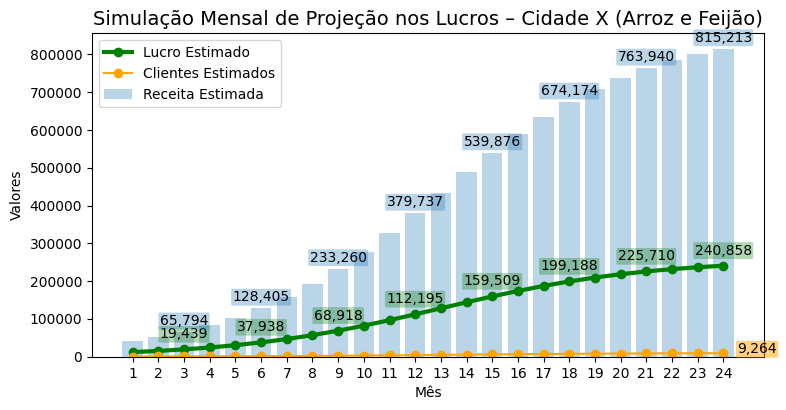

In [66]:
# Gráfico um poquinho mais complexo: visualizando o comportamento de cada categoria em cada cidade
# Fiz uma função, pois vou reutilizar isso aqui mais para frente
def plot_categoria_por_cidade(df):
    plt.figure(figsize=(8, 4))

    # plota receita como barras (fundo)
    plt.bar(df["Mes"], df["Receita_estimado"], alpha=0.3, label="Receita Estimada")

    # linha principal: lucro
    plt.plot(df["Mes"], df["Lucro_estimado"], linewidth=3, marker="o", label="Lucro Estimado", color='g')

    # linha secundária: clientes
    plt.plot(df["Mes"], df["Clientes_estimados"], linewidth=1.5, marker="o", label="Clientes Estimados", color='orange')

    # mostrar todos os meses no eixo X
    plt.xticks(df["Mes"])

    # anotações trimestrais
    meses_trimestrais = [3, 6, 9, 12, 15, 18, 21, 24]

    for m in meses_trimestrais:
        if m in df["Mes"].values:

            row = df.loc[df["Mes"] == m].iloc[0]

            lucro_m = row["Lucro_estimado"]
            receita_m = row["Receita_estimado"]

            # anotação do lucro
            plt.annotate(
                f"{lucro_m:,.0f}",
                (m, lucro_m),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                bbox=dict(boxstyle="round,pad=0.1", fc="green", ec="none", alpha=0.3)
            )

            # anotação da receita
            plt.annotate(
                f"{receita_m:,.0f}",
                (m, receita_m),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                bbox=dict(boxstyle="round,pad=0.1", ec="none", alpha=0.3)
            )

    # anotação dos clientes
    ultimo_mes = df["Mes"].max()
    row_last = df.loc[df["Mes"] == ultimo_mes].iloc[0]
    clientes_last = row_last["Clientes_estimados"]

    plt.annotate(
        f"{clientes_last:,.0f}",
        (ultimo_mes, clientes_last),
        xytext=(10, 0),
        textcoords="offset points",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.1", fc="orange", ec="none", alpha=0.5)
    )

    plt.xlabel("Mês")
    plt.ylabel("Valores")
    plt.legend()
    plt.tight_layout()

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade X (Arroz e Feijão)", fontsize=14)
plt.show()

# <br>Criando os gráficos por cidade
Agora que nós já temos os gráficos prontos e todos os dados de que precisamos, está na hora de plotar os gráficos de cidade x categoria depois de ter aplicado uma pequena simulação do CAC. Serão 3 gráficos por cidade, um para cada categoria, então:
<br><br>
- Cidade X: Gráfico de Arroz e Feijão, Fitness e Especiais
- Cidade Y: Gráfico de Arroz e Feijão, Fitness e Especiais
- **...**

<br>Com isso poderemos ver e interpretar de verdade como cada tipo de categoria se comportará em cada cidade!

## Cidade X

### Total

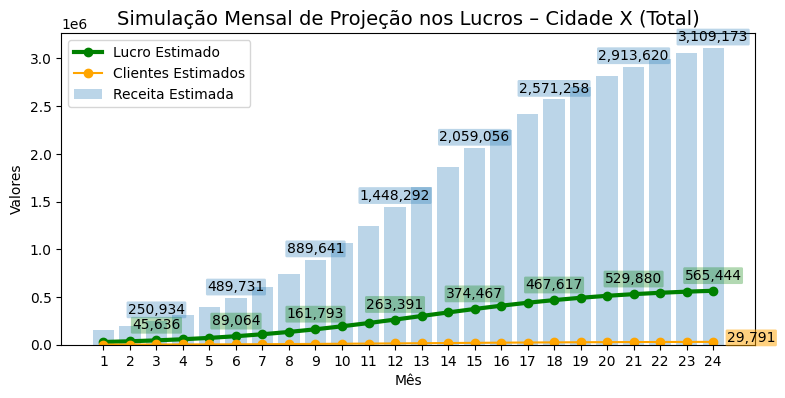

In [67]:
df_total = (
    df_projecao
    .loc[df_projecao["Municipio"] == "Cidade X"]
    .groupby("Mes")[["Clientes_estimados", "Receita_estimado", "Lucro_estimado"]]
    .sum()
    .reset_index()
)

plot_categoria_por_cidade(df_total)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade X (Total)", fontsize=14)
plt.show()

### Arroz e Feijão

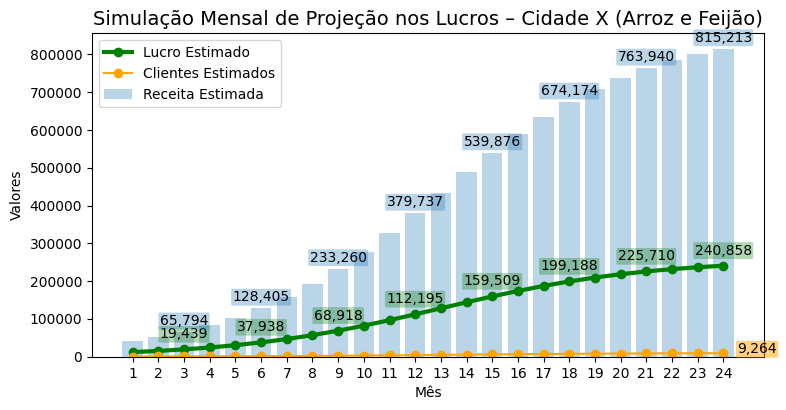

In [68]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade X'].loc[df_projecao['Categoria'] == 'Arroz e Feijão']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade X (Arroz e Feijão)", fontsize=14)
plt.show()

### Fitness

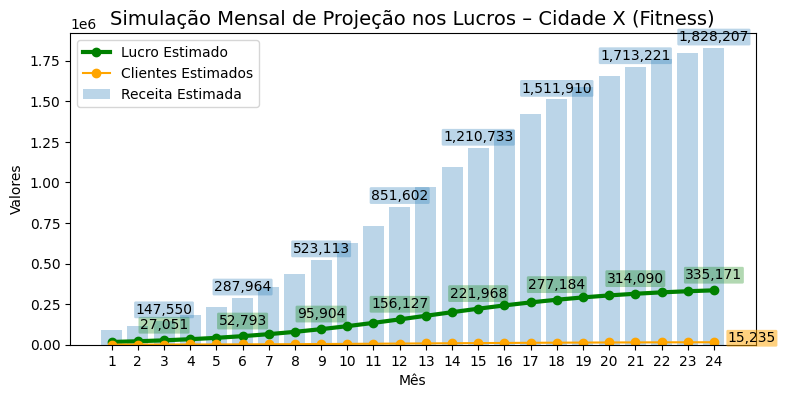

In [69]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade X'].loc[df_projecao['Categoria'] == 'Fitness']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade X (Fitness)", fontsize=14)
plt.show()

### Especiais

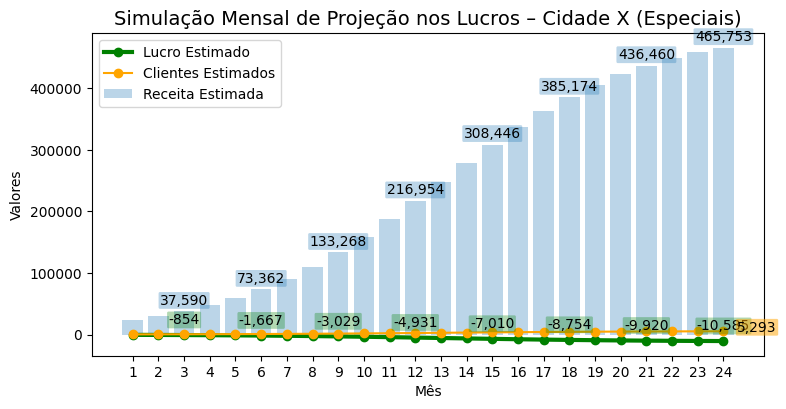

In [70]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade X'].loc[df_projecao['Categoria'] == 'Especiais']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade X (Especiais)", fontsize=14)
plt.show()

## Cidade Y

### Total

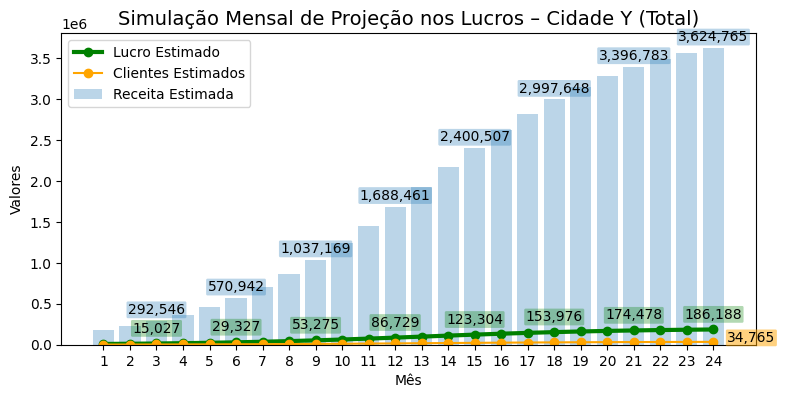

In [71]:
df_total = (
    df_projecao
    .loc[df_projecao["Municipio"] == "Cidade Y"]
    .groupby("Mes")[["Clientes_estimados", "Receita_estimado", "Lucro_estimado"]]
    .sum()
    .reset_index()
)

plot_categoria_por_cidade(df_total)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade Y (Total)", fontsize=14)
plt.show()

### Arroz e Feijão

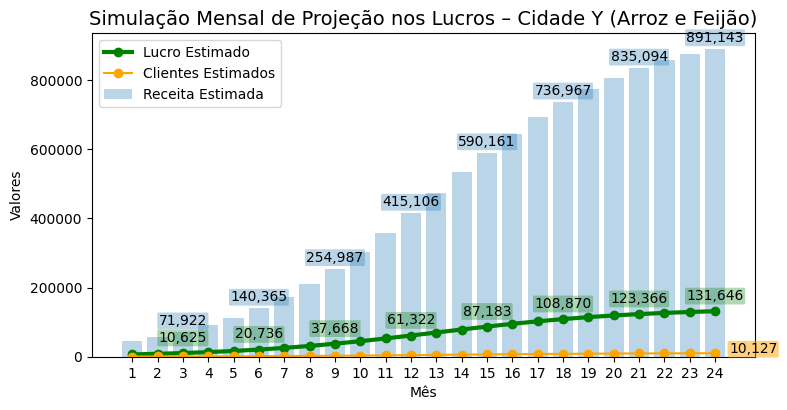

In [72]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade Y'].loc[df_projecao['Categoria'] == 'Arroz e Feijão']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade Y (Arroz e Feijão)", fontsize=14)
plt.show()

### Fitness

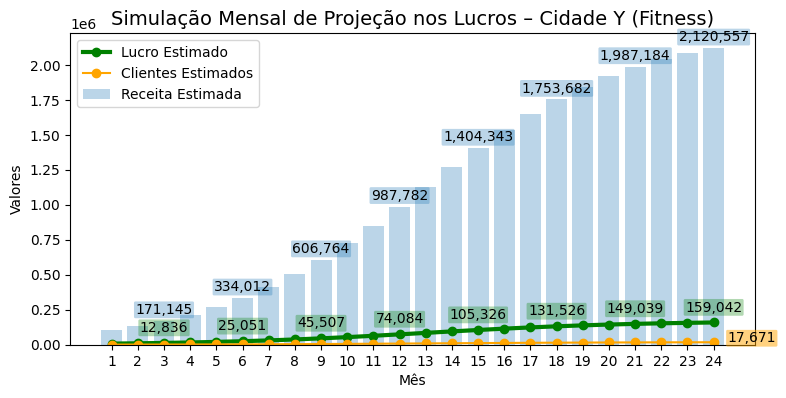

In [73]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade Y'].loc[df_projecao['Categoria'] == 'Fitness']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade Y (Fitness)", fontsize=14)
plt.show()

### Especiais

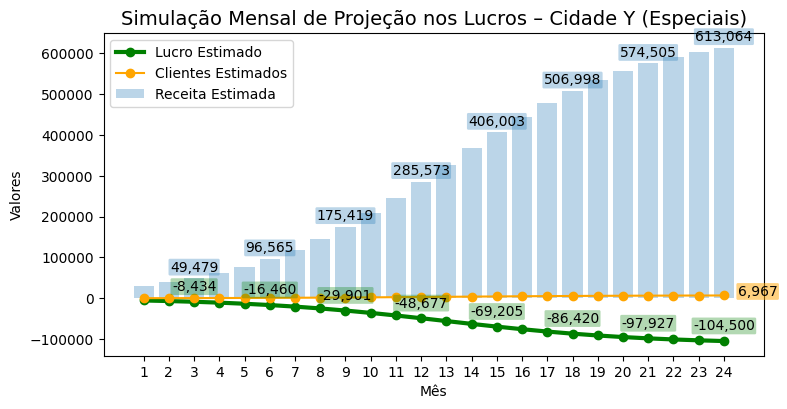

In [74]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade Y'].loc[df_projecao['Categoria'] == 'Especiais']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade Y (Especiais)", fontsize=14)
plt.show()

## Cidade Z

### Total

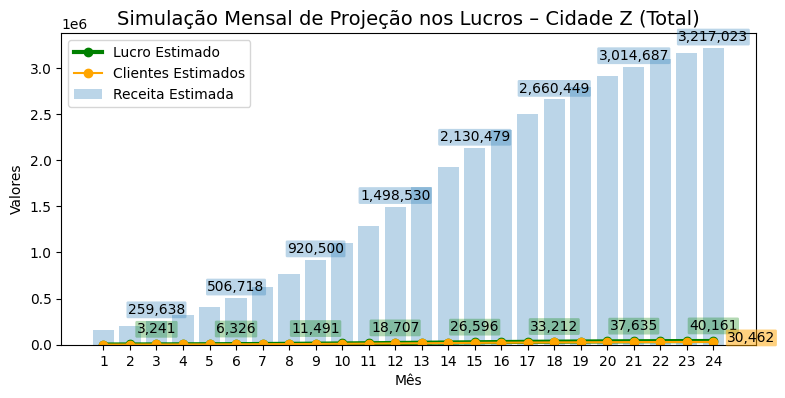

In [75]:
df_total = (
    df_projecao
    .loc[df_projecao["Municipio"] == "Cidade Z"]
    .groupby("Mes")[["Clientes_estimados", "Receita_estimado", "Lucro_estimado"]]
    .sum()
    .reset_index()
)

plot_categoria_por_cidade(df_total)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade Z (Total)", fontsize=14)
plt.show()

### Arroz e Feijão

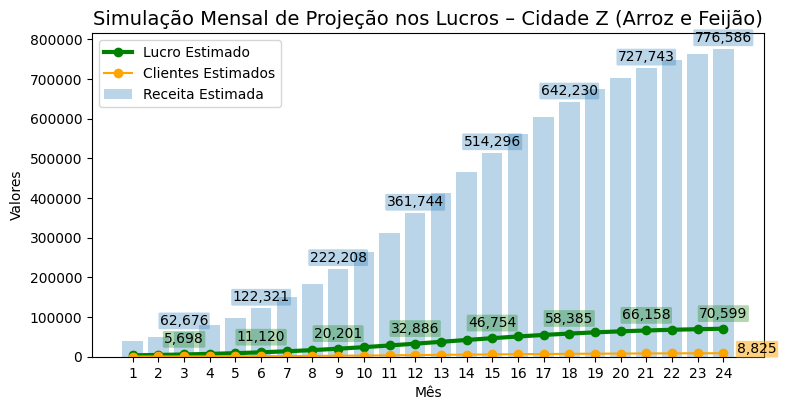

In [76]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade Z'].loc[df_projecao['Categoria'] == 'Arroz e Feijão']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade Z (Arroz e Feijão)", fontsize=14)
plt.show()

### Fitness

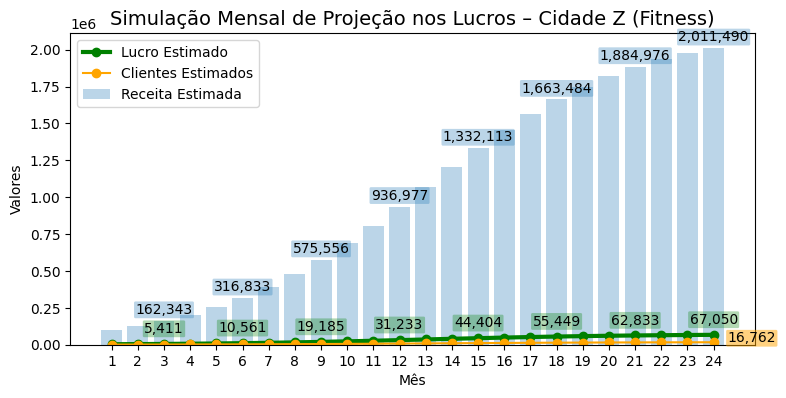

In [77]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade Z'].loc[df_projecao['Categoria'] == 'Fitness']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade Z (Fitness)", fontsize=14)
plt.show()

### Especiais

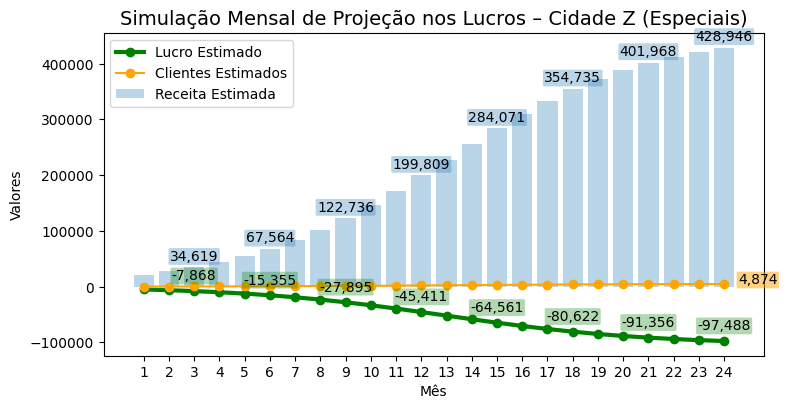

In [78]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade Z'].loc[df_projecao['Categoria'] == 'Especiais']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade Z (Especiais)", fontsize=14)
plt.show()

## Cidade W

### Total

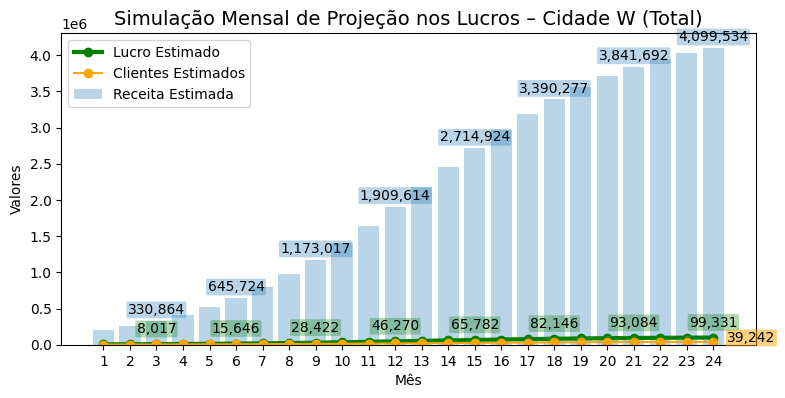

In [79]:
df_total = (
    df_projecao
    .loc[df_projecao["Municipio"] == "Cidade W"]
    .groupby("Mes")[["Clientes_estimados", "Receita_estimado", "Lucro_estimado"]]
    .sum()
    .reset_index()
)

plot_categoria_por_cidade(df_total)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade W (Total)", fontsize=14)
plt.show()

### Arroz e Feijão

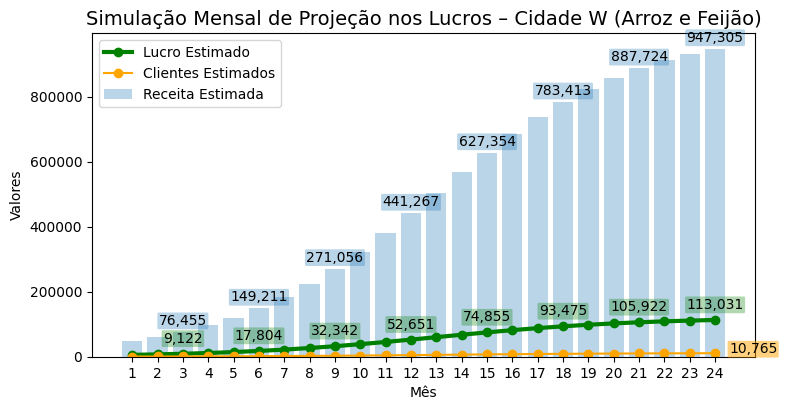

In [80]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade W'].loc[df_projecao['Categoria'] == 'Arroz e Feijão']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade W (Arroz e Feijão)", fontsize=14)
plt.show()

### Fitness

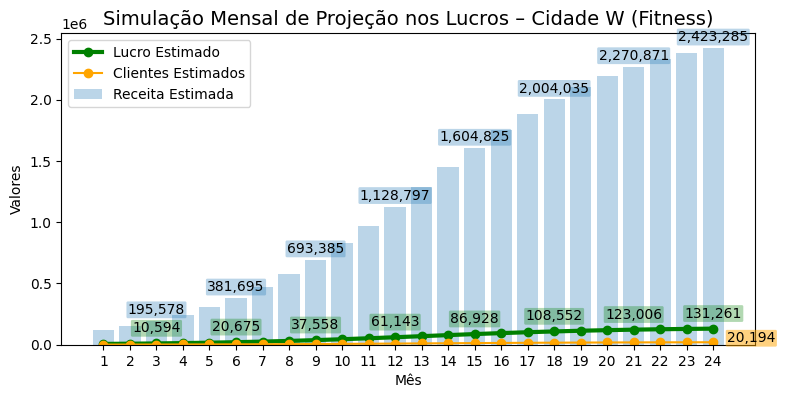

In [81]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade W'].loc[df_projecao['Categoria'] == 'Fitness']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade W (Fitness)", fontsize=14)
plt.show()

### Especiais

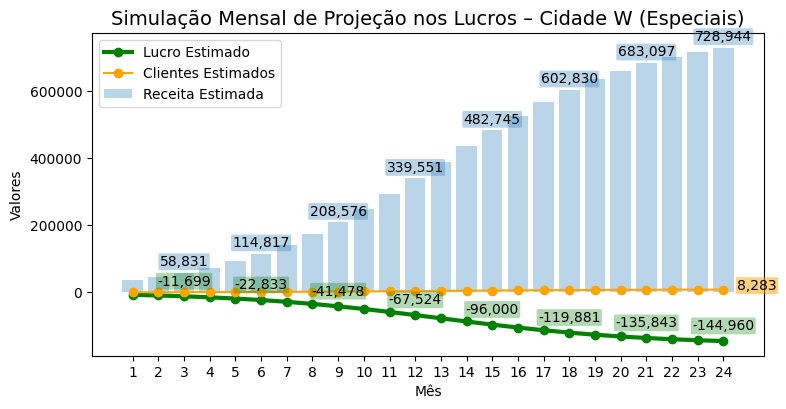

In [82]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade W'].loc[df_projecao['Categoria'] == 'Especiais']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade W (Especiais)", fontsize=14)
plt.show()

## Cidade G

### Total

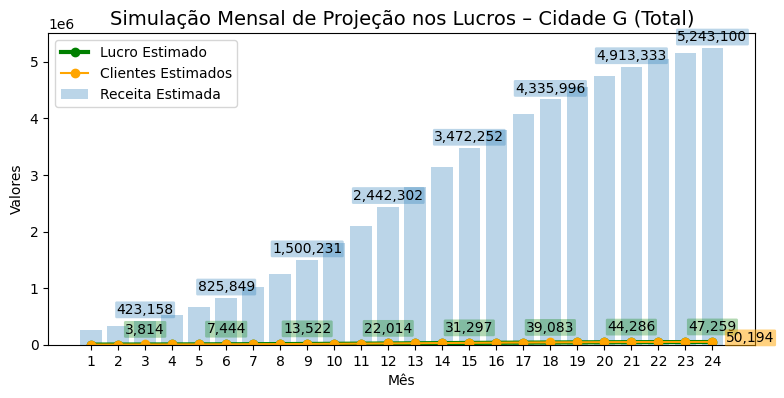

In [83]:
df_total = (
    df_projecao
    .loc[df_projecao["Municipio"] == "Cidade G"]
    .groupby("Mes")[["Clientes_estimados", "Receita_estimado", "Lucro_estimado"]]
    .sum()
    .reset_index()
)

plot_categoria_por_cidade(df_total)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade G (Total)", fontsize=14)
plt.show()

### Arroz e Feijão

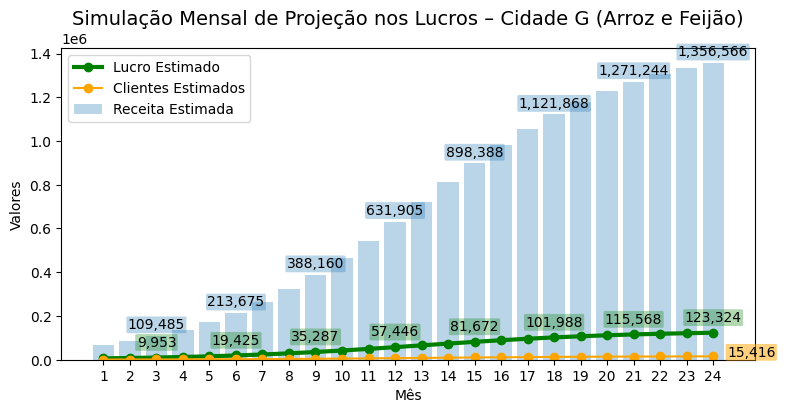

In [84]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade G'].loc[df_projecao['Categoria'] == 'Arroz e Feijão']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade G (Arroz e Feijão)", fontsize=14)
plt.show()

### Fitness

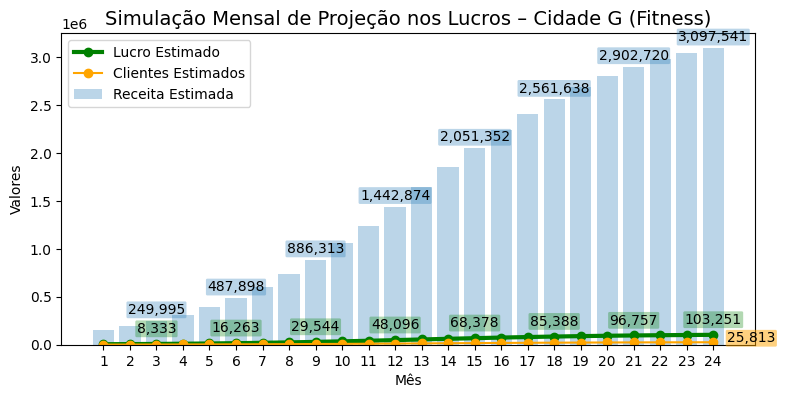

In [85]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade G'].loc[df_projecao['Categoria'] == 'Fitness']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade G (Fitness)", fontsize=14)
plt.show()

### Especiais

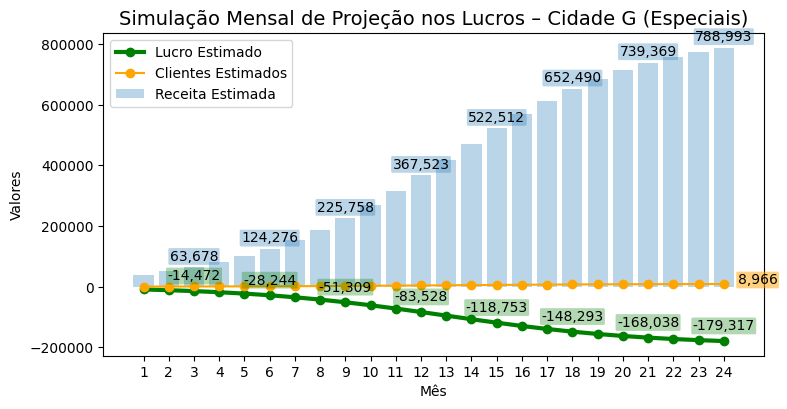

In [86]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade G'].loc[df_projecao['Categoria'] == 'Especiais']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade G (Especiais)", fontsize=14)
plt.show()

## Cidade F

### Total

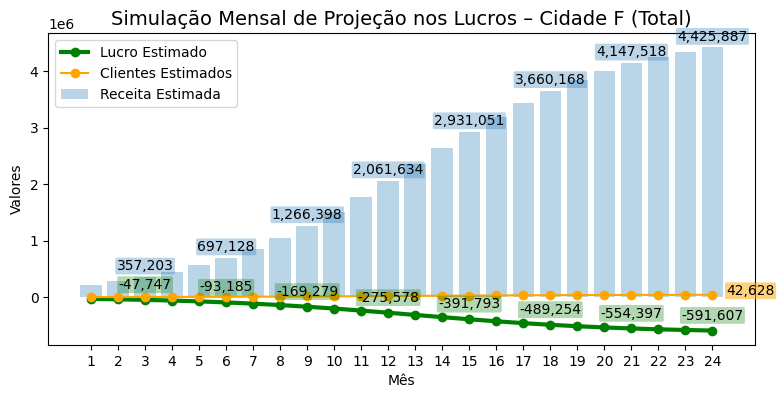

In [87]:
df_total = (
    df_projecao
    .loc[df_projecao["Municipio"] == "Cidade F"]
    .groupby("Mes")[["Clientes_estimados", "Receita_estimado", "Lucro_estimado"]]
    .sum()
    .reset_index()
)

plot_categoria_por_cidade(df_total)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade F (Total)", fontsize=14)
plt.show()

### Arroz e Feijão

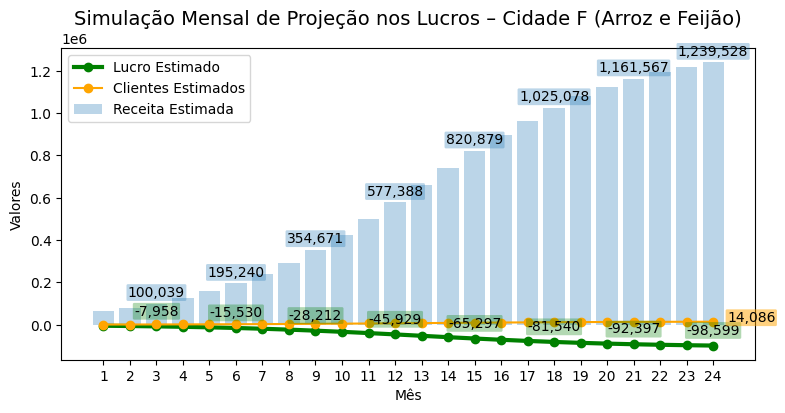

In [88]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade F'].loc[df_projecao['Categoria'] == 'Arroz e Feijão']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade F (Arroz e Feijão)", fontsize=14)
plt.show()

### Fitness

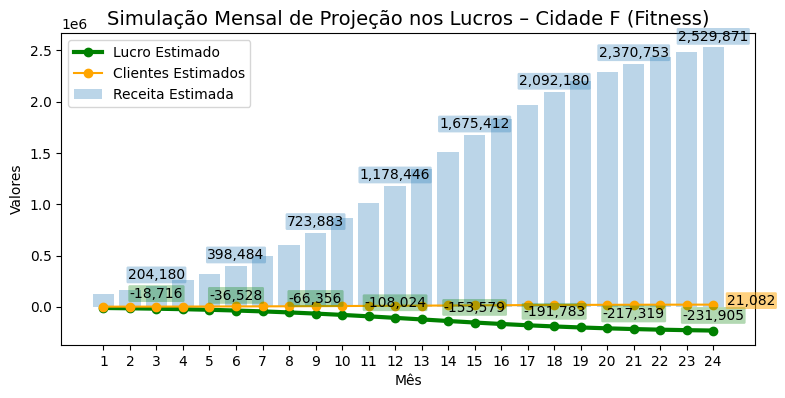

In [89]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade F'].loc[df_projecao['Categoria'] == 'Fitness']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade F (Fitness)", fontsize=14)
plt.show()

### Especiais

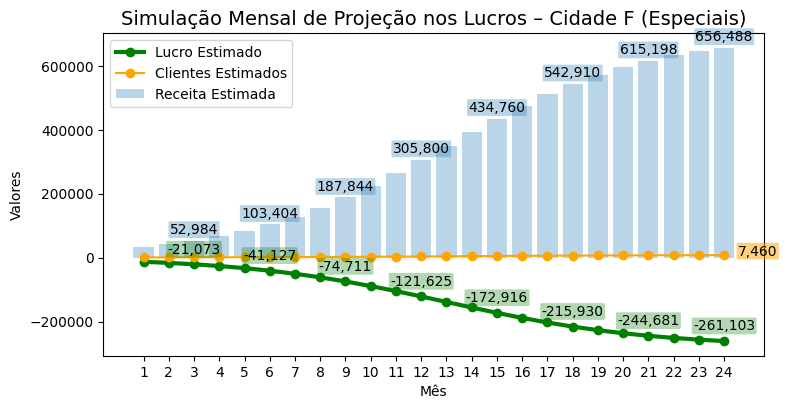

In [90]:
df = df_projecao.loc[df_projecao['Municipio'] == 'Cidade F'].loc[df_projecao['Categoria'] == 'Especiais']

plot_categoria_por_cidade(df)
plt.title("Simulação Mensal de Projeção nos Lucros – Cidade F (Especiais)", fontsize=14)
plt.show()

---

---

---